In [1]:
import json, re
import pandas as pd
 
CUSTOM_FIELD_MAP = {
    "neci8m1ih2": "schedule",
    "6hqa392kmt": "closures_reschedules",
    "r9lac8vy2c": "food_provided",
    "cooifgou2h": "eligibility",
    "t79gvzzldl": "service_notes",
}
 
def load_from_file(path):
    text = open(path, encoding="utf-8").read()
    match = re.search(r"```json\s*\n(.*?)\n```", text, re.DOTALL)
    if not match:
        raise ValueError(f"No json code block found in {path}")
    return json.loads(match.group(1))
 
def parse_custom_fields(raw):
    if not raw:
        return {}
    try:
        parsed = json.loads(raw)
    except (json.JSONDecodeError, TypeError):
        return {}
    return {CUSTOM_FIELD_MAP.get(k, k): v for k, v in parsed.items()}
 
def to_dataframe(payload):
    locations = payload["results"]["locations"]
    rows = []
    for loc in locations:
        custom = parse_custom_fields(loc.get("custom_fields"))
        rows.append({
            "id": loc.get("id"),
            "name": loc.get("name"),
            "address": loc.get("streetaddress"),
            "latitude": loc.get("loc_lat"),
            "longitude": loc.get("loc_long"),
            "phone": loc.get("phone") or None,
            "website": loc.get("website") or None,
            "tags": loc.get("tags"),
            "schedule": custom.get("schedule"),
            "closures_reschedules": custom.get("closures_reschedules"),
            "food_provided": custom.get("food_provided"),
            "eligibility": custom.get("eligibility"),
            "service_notes": custom.get("service_notes"),
        })
    df = pd.DataFrame(rows)
    df["tags_list"] = df["tags"].fillna("").apply(
        lambda s: [t.strip() for t in s.split(",") if t.strip()]
    )
    return df
 
# ---- point this at wherever you saved the file ----
payload = load_from_file("san-diego-food-bank-locations.md")
df = to_dataframe(payload)
 
print(df.shape)
df.head()

(156, 14)


,id,name,address,latitude,longitude,phone,website,tags,schedule,closures_reschedules,food_provided,eligibility,service_notes,tags_list
0,54637170,Aguilas del Poderoso Dios,"5901 Rancho Hills Drive, San Diego, CA 92139",32.672252,-117.061430,NaN,None,"thursday,neighborhood distribution",1st and 3rd Thursday of the month 10:00am unti...,"Reschedules: January 8 and January 22, 2026. C...",25-30 pounds of fresh produce; occasional dry ...,All are welcome,"Walk-up & drive-thru services; if walking up, ...","[thursday, neighborhood distribution]"
1,49902111,All Saint Episcopal Church,"651 Eucalyptus Avenue, Vista, CA 92084",33.202163,-117.234913,NaN,None,"food to nonprofit,saturday",3rd and 4th Saturday of each month; 11 AM - 12...,NaN,Nonperishable dry goods and fresh produce,All are welcome,NaN,"[food to nonprofit, saturday]"
2,49902112,Apostolic Assembly Church,"1717 East Lincoln Avenue, Escondido, CA 92027",33.143996,-117.063386,NaN,None,"saturday,neighborhood distribution",3rd Saturday of the month from 9:30 am to 10:3...,"January 10, 2026",25-30 pounds of fresh produce; occasional dry ...,NaN,Drive-thru services only; Food Bank ID cards a...,"[saturday, neighborhood distribution]"
3,49902113,Apostolic Assembly First Church San Diego,"611 South 35th St, San Diego, CA 92113",32.699690,-117.118156,NaN,None,"thursday,efap",2nd Thursday of each month from 10:00 am - 12:...,No holiday reschedules for 2026,Food menu changes monthly. Typical food packag...,Emergency Food Assistance Program Income Guide...,"Walk-up & drive-thru services; if walking up, ...","[thursday, efap]"
4,49902166,Armed Services YMCA Camp Pendleton,Building 200090 Ash Road and Wire Mountain Roa...,33.222690,-117.380070,NaN,None,"friday,efap",4th Friday of the month from 9:15 am - 11:45 am,"Rescheduled to: May 29, Nov 20, Dec 11",Food menu changes monthly. Typical food packag...,Emergency Food Assistance Program Income Guide...,Military base access required to reach this site.,"[friday, efap]"


In [2]:
df = df.drop(columns=["id"])

In [3]:
import re

SD_COUNTY_CITIES = sorted([
    "Jacumba Hot Springs", "Rancho Santa Fe", "Valley Center", "Borrego Springs",
    "Imperial Beach", "National City", "Lemon Grove", "Spring Valley",
    "Pine Valley", "Chula Vista", "San Marcos", "El Cajon", "La Mesa",
    "San Diego", "Escondido", "Oceanside", "Carlsbad", "Encinitas",
    "Solana Beach", "Del Mar", "Coronado", "Lakeside", "Alpine", "Ramona",
    "Fallbrook", "Bonsall", "Jamul", "Jacumba", "Boulevard", "Descanso",
    "Julian", "Potrero", "Campo", "Tecate", "Vista", "Poway", "Santee",
], key=len, reverse=True)

In [4]:
CITY_PATTERN = re.compile(
    r"\b(" + "|".join(re.escape(c) for c in SD_COUNTY_CITIES) + r")\b",
    re.IGNORECASE,
)
FALLBACK_CITY_PATTERN = re.compile(r"([A-Za-z][A-Za-z\s\.]*?),\s*CA\b")
 
SD_COUNTY_PLACES = SD_COUNTY_CITIES + [
    "San Ysidro", "Nestor", "Dulzura", "Pauma Valley", "Guatay",
    "Warner Springs", "Otay Mesa", "Bonita", "Rancho Bernardo",
    "Rancho Penasquitos", "Mira Mesa", "Clairemont", "Pacific Beach",
    "La Jolla", "Point Loma", "Pala", "Pauma", "Mount Laguna",
]
IMPERIAL_COUNTY_PLACES = [
    "El Centro", "Calexico", "Brawley", "Imperial", "Holtville",
    "Westmorland", "Calipatria", "Niland", "Seeley", "Heber",
    "Ocotillo", "Winterhaven",
]
COUNTY_MAP = {}
COUNTY_MAP.update({c.title(): "San Diego County" for c in SD_COUNTY_PLACES})
COUNTY_MAP.update({c.title(): "Imperial County" for c in IMPERIAL_COUNTY_PLACES})

In [5]:
def extract_zip(address):
    if not isinstance(address, str):
        return None
    match = re.search(r"(\d{5})(?:-\d{4})?\s*(?:,?\s*US)?\s*$", address)
    return match.group(1) if match else None

In [6]:
def extract_city(address):
    if not isinstance(address, str):
        return None
    matches = CITY_PATTERN.findall(address)
    if matches:
        return matches[-1].title()
    fallback = FALLBACK_CITY_PATTERN.findall(address)
    return fallback[-1].strip().title() if fallback else None

In [7]:
def get_county(city):
    if not isinstance(city, str):
        return None
    return COUNTY_MAP.get(city.title())

In [8]:
df

,name,address,latitude,longitude,phone,website,tags,schedule,closures_reschedules,food_provided,eligibility,service_notes,tags_list
0,Aguilas del Poderoso Dios,"5901 Rancho Hills Drive, San Diego, CA 92139",32.672252,-117.061430,NaN,None,"thursday,neighborhood distribution",1st and 3rd Thursday of the month 10:00am unti...,"Reschedules: January 8 and January 22, 2026. C...",25-30 pounds of fresh produce; occasional dry ...,All are welcome,"Walk-up & drive-thru services; if walking up, ...","[thursday, neighborhood distribution]"
1,All Saint Episcopal Church,"651 Eucalyptus Avenue, Vista, CA 92084",33.202163,-117.234913,NaN,None,"food to nonprofit,saturday",3rd and 4th Saturday of each month; 11 AM - 12...,NaN,Nonperishable dry goods and fresh produce,All are welcome,NaN,"[food to nonprofit, saturday]"
2,Apostolic Assembly Church,"1717 East Lincoln Avenue, Escondido, CA 92027",33.143996,-117.063386,NaN,None,"saturday,neighborhood distribution",3rd Saturday of the month from 9:30 am to 10:3...,"January 10, 2026",25-30 pounds of fresh produce; occasional dry ...,NaN,Drive-thru services only; Food Bank ID cards a...,"[saturday, neighborhood distribution]"
3,Apostolic Assembly First Church San Diego,"611 South 35th St, San Diego, CA 92113",32.699690,-117.118156,NaN,None,"thursday,efap",2nd Thursday of each month from 10:00 am - 12:...,No holiday reschedules for 2026,Food menu changes monthly. Typical food packag...,Emergency Food Assistance Program Income Guide...,"Walk-up & drive-thru services; if walking up, ...","[thursday, efap]"
4,Armed Services YMCA Camp Pendleton,Building 200090 Ash Road and Wire Mountain Roa...,33.222690,-117.380070,NaN,None,"friday,efap",4th Friday of the month from 9:15 am - 11:45 am,"Rescheduled to: May 29, Nov 20, Dec 11",Food menu changes monthly. Typical food packag...,Emergency Food Assistance Program Income Guide...,Military base access required to reach this site.,"[friday, efap]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,Us 4 Warriors,"900 Paseo del Rey, Chula Vista, CA 91910",32.633457,-117.027515,NaN,None,"tuesday,neighborhood distribution",4th Tuesday of the month from 12:00pm - 1:00pm,All distributions will be held on regularly sc...,25-30 pounds of fresh produce; occasional dry ...,All are welcome,"Walk-up & drive-thru services; if walking up, ...","[tuesday, neighborhood distribution]"
152,Victory Resource Center,"1220 Third Avenue, Suite 1 Chula Vista, CA 91911",32.609358,-117.067768,NaN,None,"efap,monday,wednesday,friday","Starting January 28th; Mondays, Wednesdays, an...","Closed in 2026 on: Feb 13, Feb 16, Mar 30, Apr...",Food menu changes monthly. Typical food packag...,Emergency Food Assistance Program Income Guide...,NaN,"[efap, monday, wednesday, friday]"
153,Warner Springs Community Resource Center,"30950 Highway 79, Warner Springs, CA 92086",33.274217,-116.644207,NaN,None,"tuesday,efap",3rd Tuesday of the month from 8:00 am - 10:00 am,No rescheduled for 2026,Food menu changes monthly. Typical food packag...,Emergency Food Assistance Program Income Guide...,Drive-thru services only; Food Bank ID cards a...,"[tuesday, efap]"
154,Waterfront Park,"1600 Pacific Hwy, San Diego, CA 92101, US",32.721990,-117.172050,NaN,None,"wednesday,senior",3rd Wednesday of each month from 9:00 am - 10:...,No holiday reschedules,A 30 pound box of food every month that is fil...,Senior (60+) only; Senior Food Program Income ...,Walk-up services only. Please bring a cart & r...,"[wednesday, senior]"


In [9]:
DAY_TAGS = {"monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"}
SERVICE_TAGS = {"efap", "food to nonprofit", "neighborhood distribution", "senior"}
DISPLAY_NAMES = {
    "efap": "EFAP",
    "food to nonprofit": "Food To Nonprofit",
    "neighborhood distribution": "Neighborhood Distribution",
    "senior": "Senior",
}
 
 
def split_day(tags_list):
    days = [t for t in tags_list if t.lower() in DAY_TAGS]
    return ", ".join(d.title() for d in days) if days else None
 
 
def split_service_type(tags_list):
    services = [t for t in tags_list if t.lower() in SERVICE_TAGS]
    return ", ".join(DISPLAY_NAMES[s.lower()] for s in services) if services else None

In [10]:
def categorize_food(text):
    if not isinstance(text, str) or not text.strip():
        return None
    t = text.lower()
 
    has_tefap = "shelf-stable" in t and "menu changes" in t
    has_senior_box = "30 pound box" in t
    has_reduced_box = "15-25 pound box" in t
    has_produce = "pounds of fresh produce" in t or "produce; occasional dry" in t
    has_generic_dry = "nonperishable dry goods and fresh produce" in t
    is_data_error = "rescheduled for" in t and "shelf-stable" not in t and "pound box" not in t
 
    if is_data_error:
        return "DATA_ERROR_NOT_FOOD_DESCRIPTION"
 
    categories = []
    if has_tefap:
        categories.append("EFAP Standard Package")
    if has_senior_box:
        categories.append("Senior 30lb Box")
    if has_reduced_box:
        categories.append("Reduced 15-25lb Box")
    if has_produce:
        categories.append("Neighborhood Produce (25-30lb)")
    if has_generic_dry:
        categories.append("Nonperishable Dry Goods + Produce")
 
    return ", ".join(categories) if categories else "Other/Uncategorized"

In [11]:
def clean_eligibility(text):
    if not isinstance(text, str) or not text.strip():
        return None
    tl = text.strip().lower()
 
    has_efap = "emergency food assistance" in tl
    has_senior = "senior" in tl and "60+" in tl
    is_open = "all are welcome" in tl
 
    if has_efap and has_senior:
        return "EFAP + Senior (Income Guidelines Apply)"
    if has_efap:
        return "EFAP Income Guidelines Apply"
    if has_senior:
        return "Senior (60+) Income Guidelines Apply"
    if is_open:
        return "Open to All"
    return text.strip()
 
 
SERVICE_NOTE_FLAGS = {
    "walkup": ["walk-up", "walk up", "walk-in", "walk in"],
    "drivethru": ["drive-thru", "drive thru"],
    "id_card_available": ["id card"],
    "bring_cart": ["bring a cart", "bring cart"],
    "diapers_period_supplies": ["diaper", "period supp"],
    "appointment_required": ["appointment"],
    "line_number_system": ["line number"],
    "military_access_required": ["military base access"],
}
 
 
def clean_service_notes(text):
    if not isinstance(text, str) or not text.strip():
        return {flag: False for flag in SERVICE_NOTE_FLAGS}
    t = text.lower()
    return {
        flag: any(phrase in t for phrase in phrases)
        for flag, phrases in SERVICE_NOTE_FLAGS.items()
    }
 
 
MONTH_PATTERN = re.compile(
    r"\b(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*\b", re.IGNORECASE
)
 
 
def clean_closures(text):
    if not isinstance(text, str) or not text.strip():
        return {"reschedule_status": "Unknown", "has_specific_dates": False}
    tl = text.strip().lower()
 
    if tl.startswith("no ") or "regularly scheduled days" in tl:
        return {"reschedule_status": "No Reschedules", "has_specific_dates": False}
 
    has_date = bool(MONTH_PATTERN.search(tl)) or bool(re.search(r"\d{1,2}/\d{1,2}", tl))
    if has_date:
        return {"reschedule_status": "Has Specific Reschedule Dates", "has_specific_dates": True}
 
    return {"reschedule_status": "Other", "has_specific_dates": False}
 
 
DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
DAY_ALT = "|".join(DAYS)
 
MONTHLY_PATTERN = re.compile(
    rf"(?:\d(?:st|nd|rd|th)|last)(?:\s*(?:,|and|&)\s*(?:\d(?:st|nd|rd|th)|last))*"
    rf"\s+(?P<day>{DAY_ALT})",
    re.IGNORECASE,
)
WEEKLY_PATTERN = re.compile(
    rf"\b(?P<days>(?:{DAY_ALT})s?(?:\s*(?:,|&|and|-|to)\s*(?:{DAY_ALT})s?)*)\b",
    re.IGNORECASE,
)
TIME_RANGE_PATTERN = re.compile(
    r"(?P<start>\d{1,2}(?::\d{2})?\s*[ap]\.?m\.?)\s*(?:-|until|to)\s*"
    r"(?P<end>\d{1,2}(?::\d{2})?\s*[ap]\.?m\.?|food (?:is gone|runs out))",
    re.IGNORECASE,
)
SINGLE_TIME_PATTERN = re.compile(r"\d{1,2}(?::\d{2})?\s*[ap]\.?m\.?", re.IGNORECASE)
 
 
def clean_schedule(text):
    if not isinstance(text, str) or not text.strip():
        return {"frequency": None, "days_of_week": None, "start_time": None,
                "end_time": None, "schedule_needs_review": True}
 
    t = text.strip()
    m = MONTHLY_PATTERN.search(t)
 
    if m:
        frequency = "Monthly"
        days_of_week = m.group("day").title()
    else:
        dm = WEEKLY_PATTERN.search(t)
        frequency = "Weekly" if dm else None
        days_of_week = dm.group("days") if dm else None
 
    times = TIME_RANGE_PATTERN.search(t)
    if times:
        start_time, end_time = times.group("start"), times.group("end")
    else:
        singles = SINGLE_TIME_PATTERN.findall(t)
        start_time = singles[0] if singles else None
        end_time = singles[1] if len(singles) > 1 else None
 
    needs_review = days_of_week is None or start_time is None
 
    return {
        "frequency": frequency,
        "days_of_week": days_of_week,
        "start_time": start_time,
        "end_time": end_time,
        "schedule_needs_review": needs_review,
    }


In [12]:
def build_dataset(md_path):
    payload = load_from_file(md_path)
    df = to_dataframe(payload)
    df = df.drop(columns=["id"])
 
    df["zip"] = df["address"].apply(extract_zip)
    df["city"] = df["address"].apply(extract_city)
    df["county"] = df["city"].apply(get_county)
 
    df["is_church"] = df["name"].str.lower().str.contains("church", na=False)
    df["is_YMCA"] = df["name"].str.lower().str.contains("ymca", na=False)
 
    df["day"] = df["tags_list"].apply(split_day)
    df["service_type"] = df["tags_list"].apply(split_service_type)
    df = df.drop(columns=["tags_list", "tags"])
 
    df["No_Phone_Number"] = df["phone"].isna()
    df["No_Website"] = df["website"].isna()
 
    df["food_category"] = df["food_provided"].apply(categorize_food)
    df = df.drop(columns=["food_provided"])
 
    # cleaning step runs directly on this same in-memory df -- no disk
    # round-trip, so there's no way for it to silently clean stale data
    df["eligibility_clean"] = df["eligibility"].apply(clean_eligibility)
 
    service_flags = df["service_notes"].apply(clean_service_notes).apply(pd.Series)
    df = pd.concat([df, service_flags], axis=1)
 
    closure_result = df["closures_reschedules"].apply(clean_closures).apply(pd.Series)
    df = pd.concat([df, closure_result], axis=1)
 
    schedule_result = df["schedule"].apply(clean_schedule).apply(pd.Series)
    df = pd.concat([df, schedule_result], axis=1)
 
    return df
 
 
if __name__ == "__main__":
    df = build_dataset("san-diego-food-bank-locations.md")

In [13]:
df

,name,address,latitude,longitude,phone,website,schedule,closures_reschedules,eligibility,service_notes,...,appointment_required,line_number_system,military_access_required,reschedule_status,has_specific_dates,frequency,days_of_week,start_time,end_time,schedule_needs_review
0,Aguilas del Poderoso Dios,"5901 Rancho Hills Drive, San Diego, CA 92139",32.672252,-117.061430,NaN,None,1st and 3rd Thursday of the month 10:00am unti...,"Reschedules: January 8 and January 22, 2026. C...",All are welcome,"Walk-up & drive-thru services; if walking up, ...",...,False,False,False,Has Specific Reschedule Dates,True,Monthly,Thursday,10:00am,food runs out,False
1,All Saint Episcopal Church,"651 Eucalyptus Avenue, Vista, CA 92084",33.202163,-117.234913,NaN,None,3rd and 4th Saturday of each month; 11 AM - 12...,NaN,All are welcome,NaN,...,False,False,False,Unknown,False,Monthly,Saturday,11 AM,12 PM.,False
2,Apostolic Assembly Church,"1717 East Lincoln Avenue, Escondido, CA 92027",33.143996,-117.063386,NaN,None,3rd Saturday of the month from 9:30 am to 10:3...,"January 10, 2026",NaN,Drive-thru services only; Food Bank ID cards a...,...,False,False,False,Has Specific Reschedule Dates,True,Monthly,Saturday,9:30 am,10:30 am,False
3,Apostolic Assembly First Church San Diego,"611 South 35th St, San Diego, CA 92113",32.699690,-117.118156,NaN,None,2nd Thursday of each month from 10:00 am - 12:...,No holiday reschedules for 2026,Emergency Food Assistance Program Income Guide...,"Walk-up & drive-thru services; if walking up, ...",...,False,False,False,No Reschedules,False,Monthly,Thursday,10:00 am,12:00 pm,False
4,Armed Services YMCA Camp Pendleton,Building 200090 Ash Road and Wire Mountain Roa...,33.222690,-117.380070,NaN,None,4th Friday of the month from 9:15 am - 11:45 am,"Rescheduled to: May 29, Nov 20, Dec 11",Emergency Food Assistance Program Income Guide...,Military base access required to reach this site.,...,False,False,True,Has Specific Reschedule Dates,True,Monthly,Friday,9:15 am,11:45 am,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,Us 4 Warriors,"900 Paseo del Rey, Chula Vista, CA 91910",32.633457,-117.027515,NaN,None,4th Tuesday of the month from 12:00pm - 1:00pm,All distributions will be held on regularly sc...,All are welcome,"Walk-up & drive-thru services; if walking up, ...",...,False,False,False,No Reschedules,False,Monthly,Tuesday,12:00pm,1:00pm,False
152,Victory Resource Center,"1220 Third Avenue, Suite 1 Chula Vista, CA 91911",32.609358,-117.067768,NaN,None,"Starting January 28th; Mondays, Wednesdays, an...","Closed in 2026 on: Feb 13, Feb 16, Mar 30, Apr...",Emergency Food Assistance Program Income Guide...,NaN,...,False,False,False,Has Specific Reschedule Dates,True,Weekly,"Mondays, Wednesdays",10:00 am,1:00 pm,False
153,Warner Springs Community Resource Center,"30950 Highway 79, Warner Springs, CA 92086",33.274217,-116.644207,NaN,None,3rd Tuesday of the month from 8:00 am - 10:00 am,No rescheduled for 2026,Emergency Food Assistance Program Income Guide...,Drive-thru services only; Food Bank ID cards a...,...,False,False,False,No Reschedules,False,Monthly,Tuesday,8:00 am,10:00 am,False
154,Waterfront Park,"1600 Pacific Hwy, San Diego, CA 92101, US",32.721990,-117.172050,NaN,None,3rd Wednesday of each month from 9:00 am - 10:...,No holiday reschedules,Senior (60+) only; Senior Food Program Income ...,Walk-up services only. Please bring a cart & r...,...,False,False,False,No Reschedules,False,Monthly,Wednesday,9:00 am,10:30 am,False


In [14]:
df = df.drop(columns=["schedule", "closures_reschedules", "eligibility", "service_notes", "phone", "website"])

In [15]:
df.head(5)

,name,address,latitude,longitude,zip,city,county,is_church,is_YMCA,day,...,appointment_required,line_number_system,military_access_required,reschedule_status,has_specific_dates,frequency,days_of_week,start_time,end_time,schedule_needs_review
0,Aguilas del Poderoso Dios,"5901 Rancho Hills Drive, San Diego, CA 92139",32.672252,-117.061430,92139,San Diego,San Diego County,False,False,Thursday,...,False,False,False,Has Specific Reschedule Dates,True,Monthly,Thursday,10:00am,food runs out,False
1,All Saint Episcopal Church,"651 Eucalyptus Avenue, Vista, CA 92084",33.202163,-117.234913,92084,Vista,San Diego County,True,False,Saturday,...,False,False,False,Unknown,False,Monthly,Saturday,11 AM,12 PM.,False
2,Apostolic Assembly Church,"1717 East Lincoln Avenue, Escondido, CA 92027",33.143996,-117.063386,92027,Escondido,San Diego County,True,False,Saturday,...,False,False,False,Has Specific Reschedule Dates,True,Monthly,Saturday,9:30 am,10:30 am,False
3,Apostolic Assembly First Church San Diego,"611 South 35th St, San Diego, CA 92113",32.699690,-117.118156,92113,San Diego,San Diego County,True,False,Thursday,...,False,False,False,No Reschedules,False,Monthly,Thursday,10:00 am,12:00 pm,False
4,Armed Services YMCA Camp Pendleton,Building 200090 Ash Road and Wire Mountain Roa...,33.222690,-117.380070,92058,Oceanside,San Diego County,False,True,Friday,...,False,False,True,Has Specific Reschedule Dates,True,Monthly,Friday,9:15 am,11:45 am,False


In [16]:
weekend = ["Saturday", "Sunday"]

In [17]:
import numpy as np
df["Weekend_Availablity"] = df["days_of_week"].fillna("").apply(
    lambda s: any(d in s for d in weekend)
)

**Data Exploration**

In [18]:
df.head(5)

,name,address,latitude,longitude,zip,city,county,is_church,is_YMCA,day,...,line_number_system,military_access_required,reschedule_status,has_specific_dates,frequency,days_of_week,start_time,end_time,schedule_needs_review,Weekend_Availablity
0,Aguilas del Poderoso Dios,"5901 Rancho Hills Drive, San Diego, CA 92139",32.672252,-117.061430,92139,San Diego,San Diego County,False,False,Thursday,...,False,False,Has Specific Reschedule Dates,True,Monthly,Thursday,10:00am,food runs out,False,False
1,All Saint Episcopal Church,"651 Eucalyptus Avenue, Vista, CA 92084",33.202163,-117.234913,92084,Vista,San Diego County,True,False,Saturday,...,False,False,Unknown,False,Monthly,Saturday,11 AM,12 PM.,False,True
2,Apostolic Assembly Church,"1717 East Lincoln Avenue, Escondido, CA 92027",33.143996,-117.063386,92027,Escondido,San Diego County,True,False,Saturday,...,False,False,Has Specific Reschedule Dates,True,Monthly,Saturday,9:30 am,10:30 am,False,True
3,Apostolic Assembly First Church San Diego,"611 South 35th St, San Diego, CA 92113",32.699690,-117.118156,92113,San Diego,San Diego County,True,False,Thursday,...,False,False,No Reschedules,False,Monthly,Thursday,10:00 am,12:00 pm,False,False
4,Armed Services YMCA Camp Pendleton,Building 200090 Ash Road and Wire Mountain Roa...,33.222690,-117.380070,92058,Oceanside,San Diego County,False,True,Friday,...,False,True,Has Specific Reschedule Dates,True,Monthly,Friday,9:15 am,11:45 am,False,False


In [19]:
df = df[df['food_category'] != "DATA_ERROR_NOT_FOOD_DESCRIPTION"]

In [20]:
df.head(5)

,name,address,latitude,longitude,zip,city,county,is_church,is_YMCA,day,...,line_number_system,military_access_required,reschedule_status,has_specific_dates,frequency,days_of_week,start_time,end_time,schedule_needs_review,Weekend_Availablity
0,Aguilas del Poderoso Dios,"5901 Rancho Hills Drive, San Diego, CA 92139",32.672252,-117.061430,92139,San Diego,San Diego County,False,False,Thursday,...,False,False,Has Specific Reschedule Dates,True,Monthly,Thursday,10:00am,food runs out,False,False
1,All Saint Episcopal Church,"651 Eucalyptus Avenue, Vista, CA 92084",33.202163,-117.234913,92084,Vista,San Diego County,True,False,Saturday,...,False,False,Unknown,False,Monthly,Saturday,11 AM,12 PM.,False,True
2,Apostolic Assembly Church,"1717 East Lincoln Avenue, Escondido, CA 92027",33.143996,-117.063386,92027,Escondido,San Diego County,True,False,Saturday,...,False,False,Has Specific Reschedule Dates,True,Monthly,Saturday,9:30 am,10:30 am,False,True
3,Apostolic Assembly First Church San Diego,"611 South 35th St, San Diego, CA 92113",32.699690,-117.118156,92113,San Diego,San Diego County,True,False,Thursday,...,False,False,No Reschedules,False,Monthly,Thursday,10:00 am,12:00 pm,False,False
4,Armed Services YMCA Camp Pendleton,Building 200090 Ash Road and Wire Mountain Roa...,33.222690,-117.380070,92058,Oceanside,San Diego County,False,True,Friday,...,False,True,Has Specific Reschedule Dates,True,Monthly,Friday,9:15 am,11:45 am,False,False


In [21]:
df.to_csv("google_maps_cleaned_data.csv")

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
pivot_table = df.pivot_table(index="city", values="name", aggfunc="count").sort_values(by="name", ascending=False)
pivot_table.rename(columns={"name": "Count of Food Bank Partners in City"})

,Count of Food Bank Partners in City
city,
San Diego,47
Chula Vista,10
Escondido,10
Spring Valley,6
El Cajon,5
Vista,5
Boulevard,5
National City,4
Ramona,4


In [24]:
sandiego = df[df["city"] == "San Diego"]
sandiego.head(5)

,name,address,latitude,longitude,zip,city,county,is_church,is_YMCA,day,...,line_number_system,military_access_required,reschedule_status,has_specific_dates,frequency,days_of_week,start_time,end_time,schedule_needs_review,Weekend_Availablity
0,Aguilas del Poderoso Dios,"5901 Rancho Hills Drive, San Diego, CA 92139",32.672252,-117.061430,92139,San Diego,San Diego County,False,False,Thursday,...,False,False,Has Specific Reschedule Dates,True,Monthly,Thursday,10:00am,food runs out,False,False
3,Apostolic Assembly First Church San Diego,"611 South 35th St, San Diego, CA 92113",32.699690,-117.118156,92113,San Diego,San Diego County,True,False,Thursday,...,False,False,No Reschedules,False,Monthly,Thursday,10:00 am,12:00 pm,False,False
5,Ascension Evangelical Lutheran Church,"5106 Zion Avenue, San Diego, CA 92120",32.793167,-117.082899,92120,San Diego,San Diego County,True,False,"Tuesday, Saturday",...,True,False,No Reschedules,False,Weekly,Tuesdays & Saturdays,8:30 am,10:30 am,False,True
6,Ascension Evangelical Lutheran Church,"6767 51st Street, San Diego, CA 92120",32.795004,-117.082747,92120,San Diego,San Diego County,True,False,Friday,...,True,False,Has Specific Reschedule Dates,True,Monthly,Friday,8:30 am,10:30 am,False,False
11,Calvary Evangelical Lutheran Church,"3060 54th Street, San Diego, CA 92105",32.737197,-117.079928,92105,San Diego,San Diego County,True,False,"Monday, Wednesday",...,False,False,Has Specific Reschedule Dates,True,Weekly,Mondays & Wednesdays,11:00 am,2:00 pm,False,False


In [25]:
sandiego_pivot = sandiego.pivot_table(index="zip", values="name", aggfunc="count").sort_values(by="name", ascending=False)
sandiego_pivot.rename(columns={"name": "Count of Food Bank Partners By Zip Code in San Diego"})

,Count of Food Bank Partners By Zip Code in San Diego
zip,
92102,7
92105,6
92154,4
92114,4
92103,3
92113,3
92117,2
92120,2
92104,2


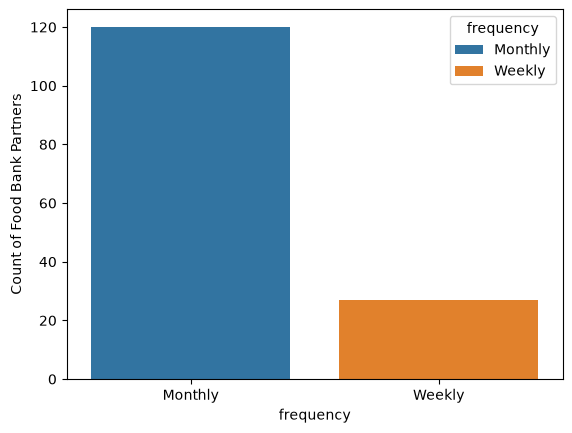

In [26]:
sns.countplot(data=df, x="frequency", hue="frequency")
plt.ylabel("Count of Food Bank Partners")
plt.show()

**What is the impact of church entites on peoples accesss to food bank partners**

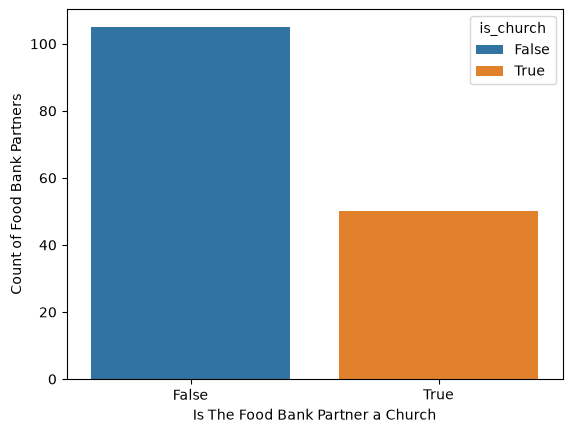

In [27]:
sns.countplot(data=df, x="is_church", hue="is_church")
plt.xlabel("Is The Food Bank Partner a Church")
plt.ylabel("Count of Food Bank Partners")
plt.show()

In [28]:
churches = df.pivot_table(index="is_church", values="name", aggfunc="count").sort_values(by="name", ascending=False)
churches = churches.rename(columns={"name": "Total"})
churches["Percent of Total"] = (churches["Total"] / churches["Total"].sum() * 100).round(1)
churches

,Total,Percent of Total
is_church,,
False,105,67.7
True,50,32.3


In [29]:
church_data = df[df["is_church"] == True]

church_city = church_data.pivot_table(index="city", values="name", aggfunc="count").sort_values(by="name", ascending=False)
church_city = church_city.rename(columns={"name": "Total"})
church_city["Percent of Total"] = (church_city["Total"] / church_city["Total"].sum() * 100).round(1)
church_city

,Total,Percent of Total
city,,
San Diego,21,42.0
Escondido,3,6.0
Poway,3,6.0
Spring Valley,3,6.0
San Marcos,2,4.0
Campo,2,4.0
Ramona,2,4.0
El Cajon,2,4.0
Fallbrook,2,4.0


In [30]:
church_san_diego = df[(df["is_church"] == True) & (df["city"] == "San Diego")]

church_zip_code = church_san_diego.pivot_table(index="zip", values="name", aggfunc="count").sort_values(by="name", ascending=False)
church_zip_code = church_zip_code.rename(columns={"name": "Total"})
church_zip_code["Percent of Total"] = (church_zip_code["Total"] / church_zip_code["Total"].sum() * 100).round(1)
church_zip_code

,Total,Percent of Total
zip,,
92105,4,19.0
92114,4,19.0
92102,2,9.5
92104,2,9.5
92120,2,9.5
92154,2,9.5
92106,1,4.8
92113,1,4.8
92110,1,4.8


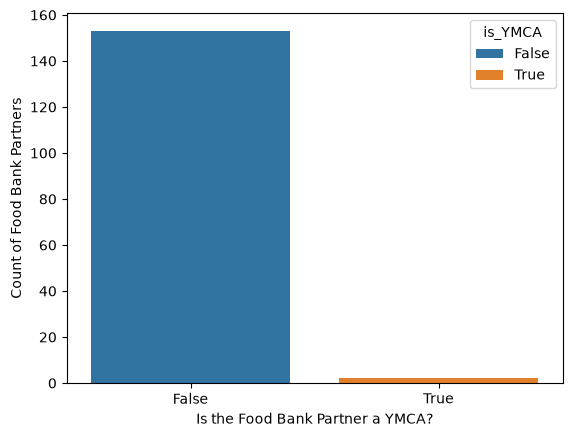

In [31]:
sns.countplot(data=df, x="is_YMCA", hue="is_YMCA")
plt.xlabel("Is the Food Bank Partner a YMCA?")
plt.ylabel("Count of Food Bank Partners")
plt.show()

In [32]:
frequency_pivot = pd.crosstab(
    df["frequency"],
    df["Weekend_Availablity"].fillna("No response")
)

frequency_pivot["Total"] = frequency_pivot.sum(axis=1)
frequency_pivot["Percent of Total"] = (frequency_pivot["Total"] / frequency_pivot["Total"].sum() * 100).round(1)

frequency_pivot

Weekend_Availablity,False,True,Total,Percent of Total
frequency,,,,
Monthly,109,11,120,81.6
Weekly,24,3,27,18.4


In [33]:
no_weekend_availability = df[df["Weekend_Availablity"] == False]

In [34]:
no_weekend_city = no_weekend_availability.pivot_table(index="city", values="name", aggfunc="count").sort_values(by="name", ascending=False)
no_weekend_city = no_weekend_city.rename(columns={"name": "Total"})
no_weekend_city["Percent of Total"] = (no_weekend_city["Total"] / no_weekend_city["Total"].sum() * 100).round(1)
no_weekend_city

,Total,Percent of Total
city,,
San Diego,40,28.4
Chula Vista,10,7.1
Escondido,8,5.7
Spring Valley,6,4.3
El Cajon,5,3.5
Boulevard,5,3.5
National City,4,2.8
Vista,4,2.8
Fallbrook,4,2.8


**Break down food partners by Military Access**

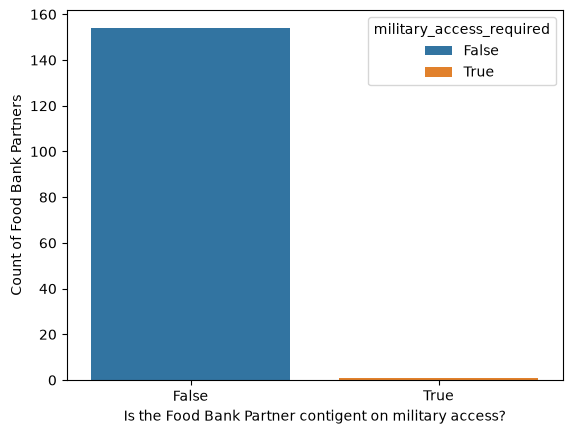

In [35]:
sns.countplot(data=df, x="military_access_required", hue="military_access_required")
plt.xlabel("Is the Food Bank Partner contigent on military access?")
plt.ylabel("Count of Food Bank Partners")
plt.show()

**Break down data by service type**

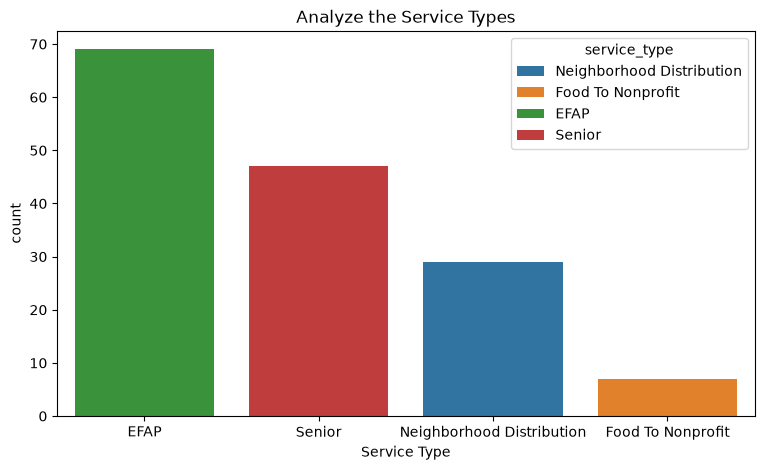

In [36]:
order1 = df["service_type"].value_counts().index
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="service_type", hue="service_type", order=order1)
plt.title("Analyze the Service Types")
plt.xlabel("Service Type")
plt.show()

In [37]:
import plotly.graph_objects as go

In [38]:
ct = pd.crosstab(df["city"], df["service_type"])

In [39]:
all_cities = df["service_type"].value_counts()
ct.loc["All Cities"] = all_cities
ct = ct.reindex(["All Cities"] + sorted(c for c in ct.index if c != "All Cities"))

In [40]:
COLOR_MAP = {
    "EFAP": "#2563eb",
    "Senior": "#f59e0b",
    "Neighborhood Distribution": "#10b981",
    "Food To Nonprofit": "#8b5cf6",
}

In [41]:
fig = go.Figure()

for i, city in enumerate(ct.index):
    row = ct.loc[city]
    nonzero = row[row > 0]
    fig.add_trace(
        go.Pie(
            labels=nonzero.index.tolist(),
            values=nonzero.values.tolist(),
            marker=dict(colors=[COLOR_MAP.get(s, "#9ca3af") for s in nonzero.index],
                        line=dict(color="white", width=2)),
            hole=0.42,
            sort=False,
            textinfo="label+percent",
            texttemplate="%{label}<br>%{value} (%{percent})",
            hovertemplate="%{label}<br>Count: %{value}<br>Share: %{percent}<extra></extra>",
            visible=(i == 0), 
            name=city,
        )
    )


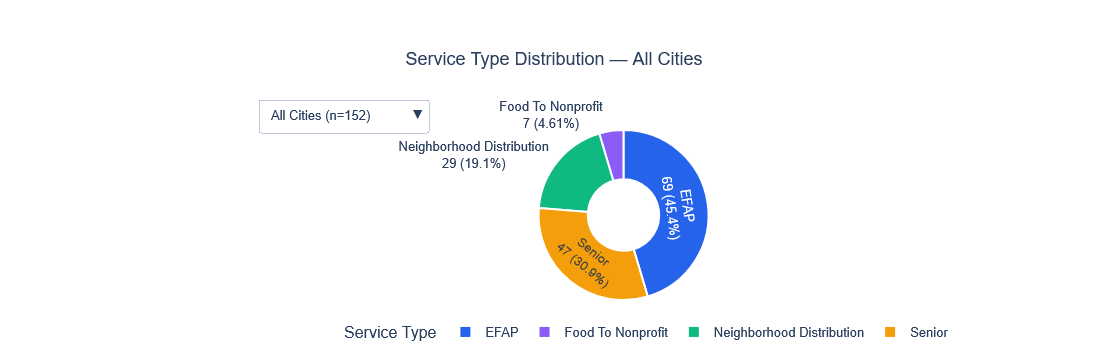

In [42]:
buttons = []
for i, city in enumerate(ct.index):
    visibility = [j == i for j in range(len(ct.index))]
    total = int(ct.loc[city].sum())
    buttons.append(
        dict(
            label=f"{city} (n={total})",
            method="update",
            args=[
                {"visible": visibility},
                {"title.text": f"Service Type Distribution — {city}"},  
            ],
        )
    )

fig.update_layout(
    title=dict(
        text="Service Type Distribution — All Cities",
        x=0.5,
        xanchor="center",
        font=dict(size=18),
    ),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=-0.15,         
            xanchor="left",
            y=1.18,
            yanchor="top",
            showactive=True,
        )
    ],
    # --- legend title ---
    legend=dict(
        title=dict(text="Service Type"),
        orientation="h",
        y=-0.1,
    ),
    margin=dict(t=130, b=40, l=100, r=20), 
    font=dict(family="Arial, sans-serif", size=13),
)

fig.show()

**Break Down Distribution of Food Programs by City of San Diego**

In [43]:
ct1 = pd.crosstab(df["city"], df["food_category"])

In [44]:
all_cities1 = df["food_category"].value_counts()
ct1.loc["All Cities"] = all_cities1
ct1 = ct1.reindex(["All Cities"] + sorted(c for c in ct1.index if c != "All Cities"))

In [45]:
df["food_category"].value_counts()

food_category
EFAP Standard Package                68
Senior 30lb Box                      48
Neighborhood Produce (25-30lb)       30
Nonperishable Dry Goods + Produce     8
Reduced 15-25lb Box                   1
Name: count, dtype: int64

In [46]:
COLOR_MAP_1 = {
    "EFAP Standard Package": "#2563eb",
    "Senior 30lb Box": "#f59e0b",
    "Neighborhood Produce (25-30lb)": "#10b981",
    "Nonperishable Dry Goods + Produce ": "#8b5cf6",
    "Reduced 15-25lb Box": "#FFC0CB"
}

In [47]:
fig = go.Figure()

for i, city in enumerate(ct.index):
    row = ct1.loc[city]
    nonzero = row[row > 0]
    fig.add_trace(
        go.Pie(
            labels=nonzero.index.tolist(),
            values=nonzero.values.tolist(),
            marker=dict(colors=[COLOR_MAP_1.get(s, "#9ca3af") for s in nonzero.index],
                        line=dict(color="white", width=2)),
            hole=0.42,
            sort=False,
            textinfo="label+percent",
            texttemplate="%{label}<br>%{value} (%{percent})",
            hovertemplate="%{label}<br>Count: %{value}<br>Share: %{percent}<extra></extra>",
            visible=(i == 0), 
            name=city,
        )
    )


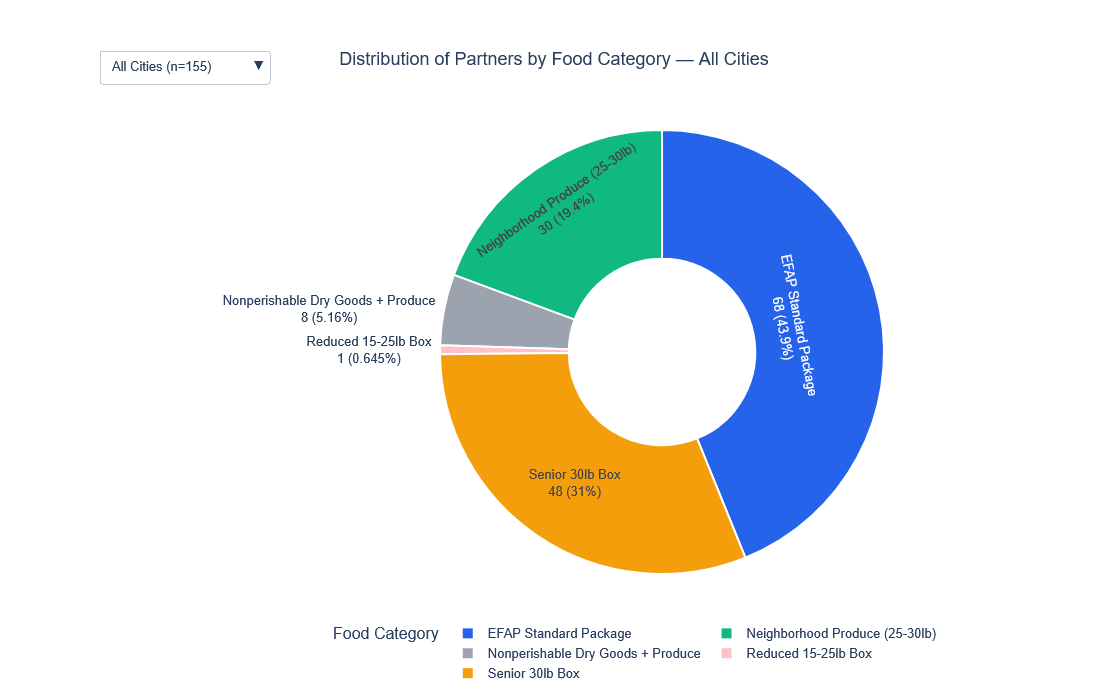

In [48]:
buttons = []
for i, city in enumerate(ct1.index):
    visibility = [j == i for j in range(len(ct1.index))]
    total = int(ct1.loc[city].sum())
    buttons.append(
        dict(
            label=f"{city} (n={total})",
            method="update",
            args=[
                {"visible": visibility},
                {"title.text": f"Distribution of Partners by Food Category — {city}"},  
            ],
        )
    )

fig.update_layout(
    title=dict(
        text="Distribution of Partners by Food Category — All Cities",
        x=0.5,
        xanchor="center",
        font=dict(size=18),
    ),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=-0.35,
            xanchor="left",
            y=1.18,
            yanchor="top",
            showactive=True,
        )
    ],
    legend=dict(
        title=dict(text="Food Category"),
        orientation="h",
        y=-0.1,
    ),
    margin=dict(t=130, b=40, l=150, r=20),
    font=dict(family="Arial, sans-serif", size=13),
    height=700,   # increase overall figure height (default is 450)
)
fig.show()

In [49]:
from sklearn.cluster import KMeans

In [50]:
cluster = df[["latitude", "longitude"]]
cluster

,latitude,longitude
0,32.672252,-117.061430
1,33.202163,-117.234913
2,33.143996,-117.063386
3,32.699690,-117.118156
4,33.222690,-117.380070
...,...,...
151,32.633457,-117.027515
152,32.609358,-117.067768
153,33.274217,-116.644207
154,32.721990,-117.172050


In [51]:
X = cluster.iloc[:, [0, 1]].values

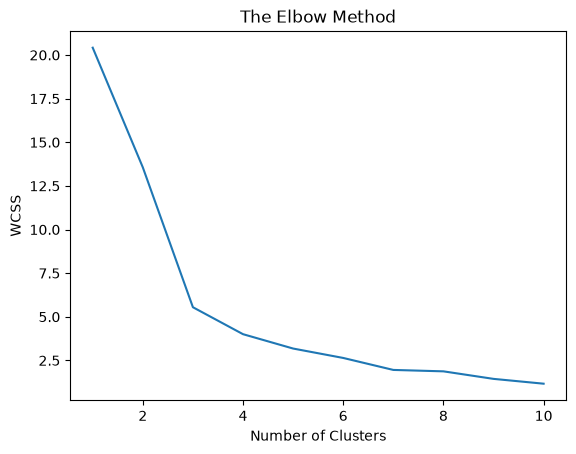

In [52]:
from sklearn.cluster import KMeans 
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init="k-means++", random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show() 

In [53]:
kmeans = KMeans(n_clusters=7, init="k-means++", random_state=42)
y_kmeans = kmeans.fit_predict(X)

In [54]:
X_df = cluster.copy()
X_df["cluster"] = y_kmeans

cluster_ranges = X_df.groupby("cluster").agg(
    count=("latitude", "size"),
    lat_min=("latitude", "min"),
    lat_max=("latitude", "max"),
    lon_min=("longitude", "min"),
    lon_max=("longitude", "max"),
).reset_index()
cluster_ranges["cluster"] = cluster_ranges["cluster"] + 1  
cluster_ranges

,cluster,count,lat_min,lat_max,lon_min,lon_max
0,1,68,32.543751,32.895915,-117.244702,-116.995918
1,2,22,32.946846,33.304969,-117.138828,-116.860196
2,3,2,32.671401,32.788858,-115.547084,-115.488707
3,4,14,32.610986,32.846782,-116.689871,-116.179638
4,5,21,33.041348,33.413660,-117.380070,-117.149562
5,6,24,32.703948,32.860716,-117.023411,-116.774182
6,7,4,33.077582,33.274217,-116.644207,-116.376640


C:\Users\alexh\AppData\Local\Temp\ipykernel_44496\2564960369.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


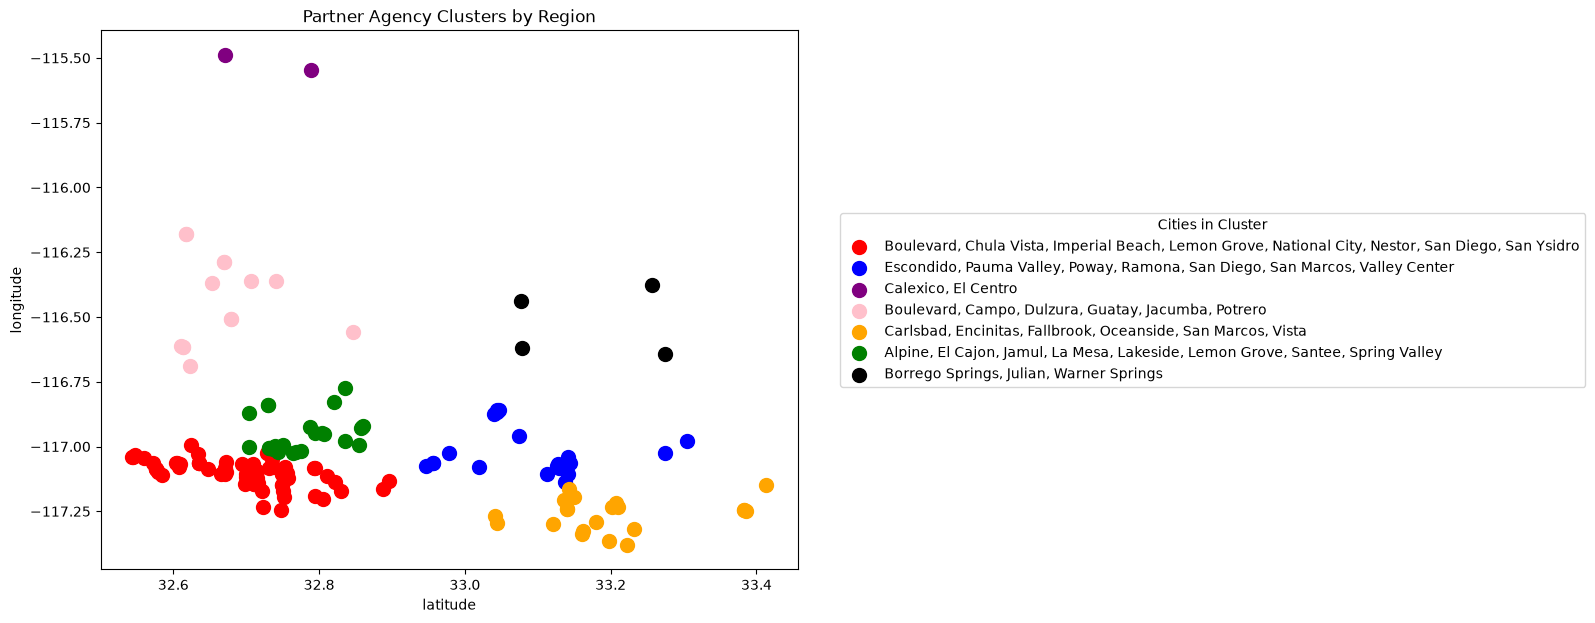

In [55]:
tmp = df.copy()
tmp["cluster"] = y_kmeans
cluster_labels = {
    c: ", ".join(sorted(tmp.loc[tmp["cluster"] == c, "city"].unique()))
    for c in sorted(tmp["cluster"].unique())
}

colors = ["red", "blue", "purple", "pink", "orange", "green", "black"]

plt.figure(figsize=(9, 7))
for c in range(7):
    plt.scatter(
        X[y_kmeans == c, 0], X[y_kmeans == c, 1],
        s=100, c=colors[c], label=cluster_labels[c],
    )

plt.title("Partner Agency Clusters by Region")
plt.xlabel("latitude")
plt.ylabel("longitude")
plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", title="Cities in Cluster")
plt.tight_layout()
plt.show()

In [56]:
REGION_ANCHORS = {
    "South Bay (Chula Vista-National City)": {"Chula Vista", "National City", "San Ysidro", "Imperial Beach", "Nestor"},
    "North Inland (Escondido-Poway-Ramona)": {"Escondido", "Poway", "Ramona", "Valley Center", "Pauma Valley"},
    "Imperial Valley Border": {"Calexico", "El Centro"},
    "Southeast Backcountry (Boulevard-Campo)": {"Campo", "Guatay", "Dulzura", "Potrero", "Jacumba"},
    "North Coastal (Vista-Oceanside-Carlsbad)": {"Carlsbad", "Oceanside", "Vista", "Encinitas", "Fallbrook"},
    "East County (El Cajon-Lakeside)": {"El Cajon", "Lakeside", "La Mesa", "Santee", "Spring Valley", "Alpine"},
    "North Backcountry (Borrego Springs-Julian-Warner Springs)": {"Borrego Springs", "Julian", "Warner Springs"},
}

In [57]:
city_group = {}
for cluster_id, city_string in cluster_labels.items():
    cities_in_cluster = set(city_string.split(", "))
    best_region, best_overlap = None, -1
    for region, anchors in REGION_ANCHORS.items():
        overlap = len(cities_in_cluster & anchors)
        if overlap > best_overlap:
            best_overlap, best_region = overlap, region
    city_group[cluster_id] = best_region

df["city_grouping"] = pd.Series(y_kmeans).map(city_group)

In [58]:
df["city_grouping"].value_counts()

city_grouping
South Bay (Chula Vista-National City)                        68
East County (El Cajon-Lakeside)                              24
North Inland (Escondido-Poway-Ramona)                        22
North Coastal (Vista-Oceanside-Carlsbad)                     20
Southeast Backcountry (Boulevard-Campo)                      14
North Backcountry (Borrego Springs-Julian-Warner Springs)     4
Imperial Valley Border                                        2
Name: count, dtype: int64

In [59]:
city_grouping_pivot = df.pivot_table(index="city_grouping", values="name", aggfunc="count").sort_values(by="name", ascending=False)
city_grouping_pivot = city_grouping_pivot.rename(columns={"name": "Total"})
city_grouping_pivot["Percent of Total"] = (city_grouping_pivot["Total"] / city_grouping_pivot["Total"].sum() * 100).round(1)
city_grouping_pivot

,Total,Percent of Total
city_grouping,,
South Bay (Chula Vista-National City),68,44.2
East County (El Cajon-Lakeside),24,15.6
North Inland (Escondido-Poway-Ramona),22,14.3
North Coastal (Vista-Oceanside-Carlsbad),20,13.0
Southeast Backcountry (Boulevard-Campo),14,9.1
North Backcountry (Borrego Springs-Julian-Warner Springs),4,2.6
Imperial Valley Border,2,1.3


In [60]:
zip_code_pivot = df.pivot_table(index="zip", values="name", aggfunc="count").sort_values(by="name", ascending=False)
zip_code_pivot.rename(columns={"name": "Unique Count of Zip Code"})

,Unique Count of Zip Code
zip,
92102,7
91977,6
92105,6
91910,5
92154,5
...,...
92126,1
92139,1
92128,1


In [61]:
import geopandas as gpd
import urllib.request
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from adjustText import adjust_text

In [62]:
url = "https://raw.githubusercontent.com/OpenDataDE/State-zip-code-GeoJSON/master/ca_california_zip_codes_geo.min.json"
urllib.request.urlretrieve(url, "ca_zips.geojson")

('ca_zips.geojson', <http.client.HTTPMessage at 0x1eb7462fa70>)

In [63]:
by_zip = (
    df.groupby("zip")["name"]
    .size()
    .reset_index()
    .rename(columns={"name": "Enrollment_Count"})
)

In [64]:
by_zip["zip"] = by_zip["zip"].astype(str)
zip_city = df.groupby("zip")["city"].agg(lambda s: s.value_counts().idxmax())
zip_city.index = zip_city.index.astype(str)

In [65]:
gdf = gpd.read_file("ca_zips.geojson")   # statewide CA zip boundaries
gdf = gdf.rename(columns={"ZCTA5CE10": "zip"})
gdf["zip"] = gdf["zip"].astype(str)

def is_sd_county_zip(z):
    n = int(z)
    return (91901 <= n <= 91980) or (92003 <= n <= 92199)

sd_gdf = gdf[gdf["zip"].apply(is_sd_county_zip)].copy()
sd_gdf = sd_gdf.merge(by_zip, on="zip", how="left")
sd_gdf["Enrollment_Count"] = sd_gdf["Enrollment_Count"].fillna(0)

C:\Users\alexh\AppData\Local\Temp\ipykernel_44496\3539464423.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sd_gdf["centroid"] = sd_gdf.geometry.centroid
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


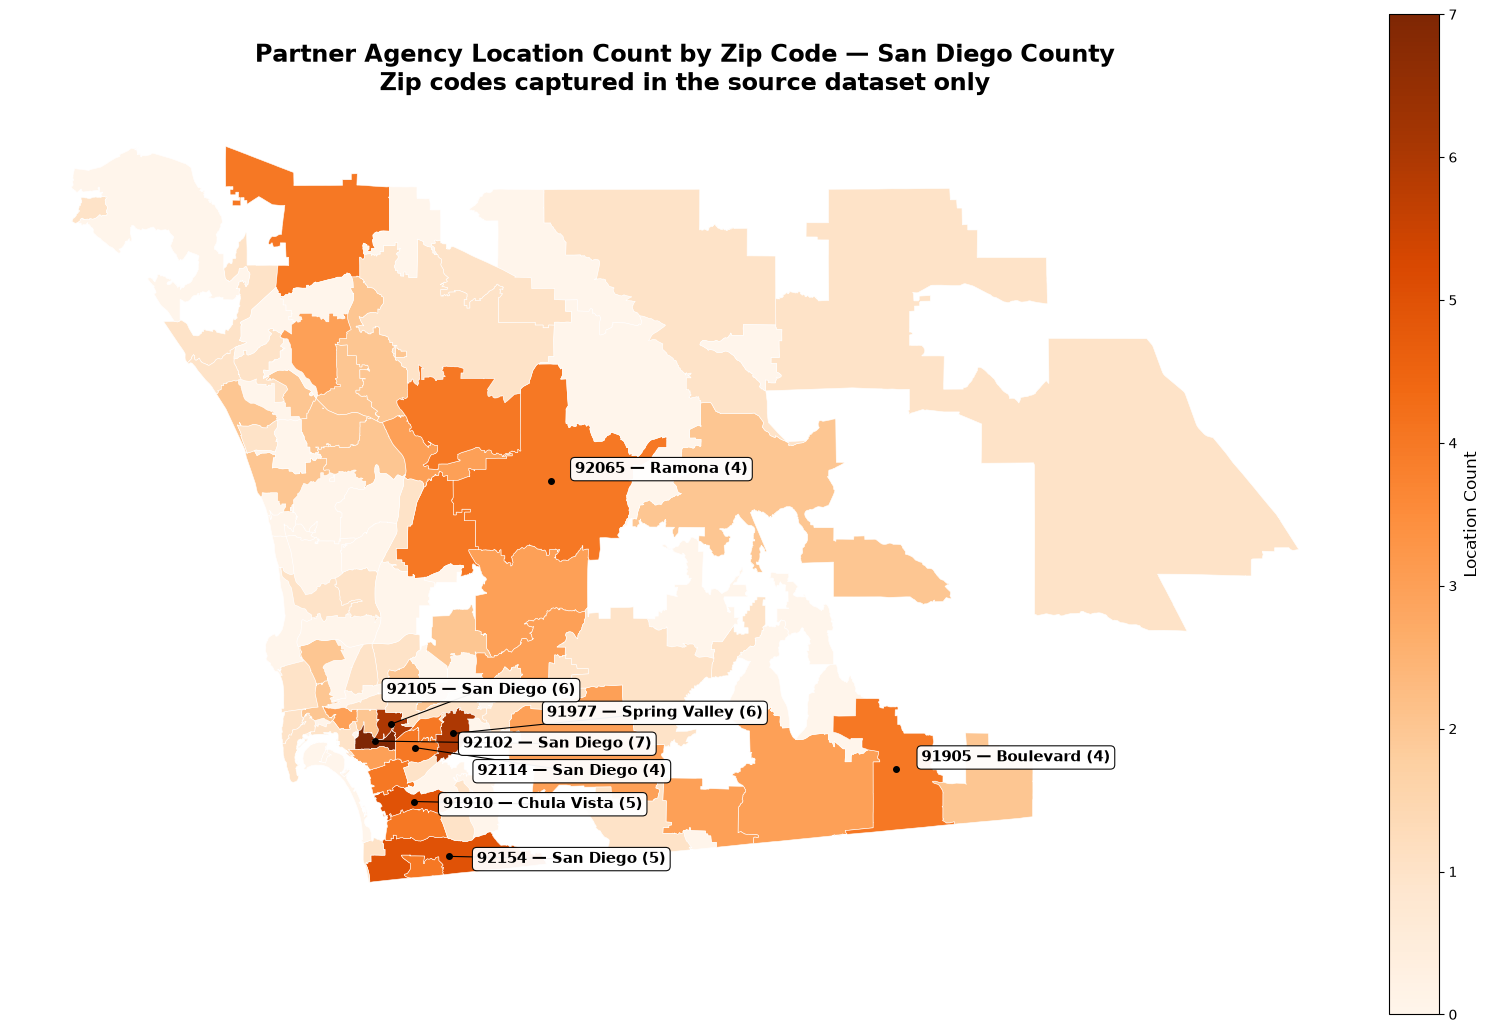

In [66]:
fig, ax = plt.subplots(figsize=(15, 11))
vmax = sd_gdf["Enrollment_Count"].max()
sd_gdf.plot(column="Enrollment_Count", cmap="Oranges", linewidth=0.4,
            edgecolor="white", ax=ax, vmin=0, vmax=vmax)
ax.set_axis_off()
ax.set_title("Partner Agency Location Count by Zip Code — San Diego County\n"
             "Zip codes captured in the source dataset only",
             fontsize=17, fontweight="bold", pad=14)

sm = ScalarMappable(cmap="Oranges", norm=Normalize(vmin=0, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Location Count", fontsize=12)

# 4. Callout labels for the top zips, auto-spread to avoid overlap
top_n = by_zip.sort_values("Enrollment_Count", ascending=False).head(8)
sd_gdf["centroid"] = sd_gdf.geometry.centroid

texts, dot_x, dot_y = [], [], []
for _, row in top_n.iterrows():
    match = sd_gdf[sd_gdf["zip"] == row["zip"]]
    if match.empty:
        continue
    c = match.iloc[0]["centroid"]
    city = zip_city.get(row["zip"], "")
    label = f"{row['zip']} — {city} ({int(row['Enrollment_Count'])})"
    ax.plot(c.x, c.y, "o", color="black", markersize=4, zorder=5)
    dot_x.append(c.x); dot_y.append(c.y)
    texts.append(ax.text(c.x, c.y, label, fontsize=10.5, fontweight="bold",
                          bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.8, alpha=0.95),
                          zorder=6))

adjust_text(texts, x=dot_x, y=dot_y,
            arrowprops=dict(arrowstyle="-", color="black", lw=0.8),
            expand_text=(1.3, 1.6), force_text=(0.6, 0.8))

plt.tight_layout()